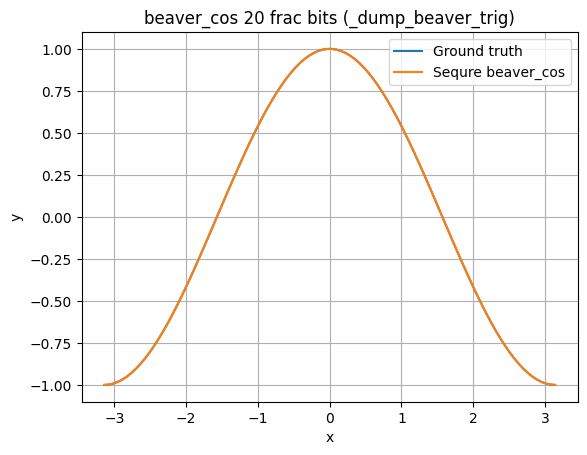

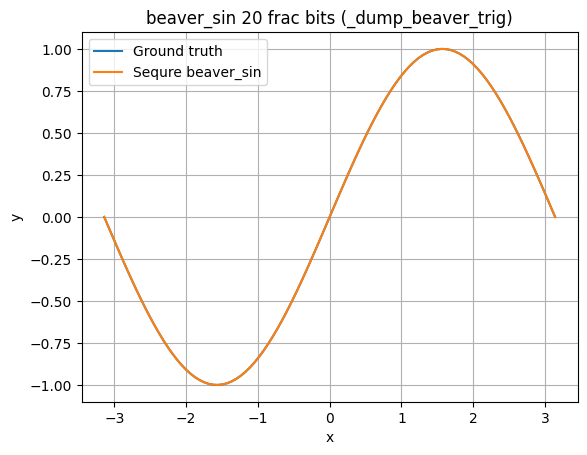

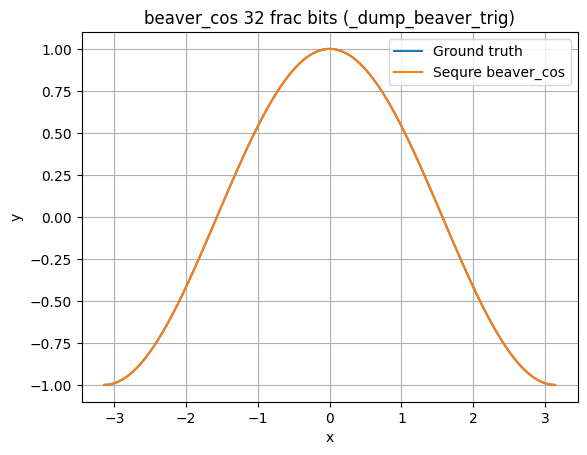

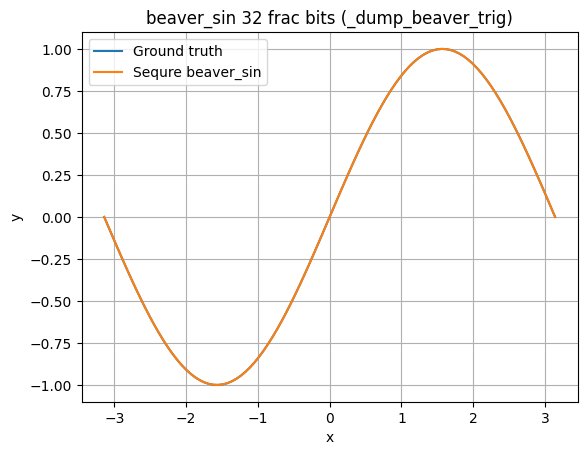

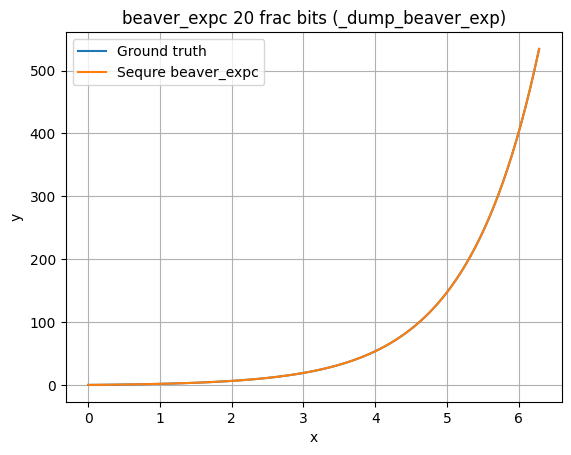

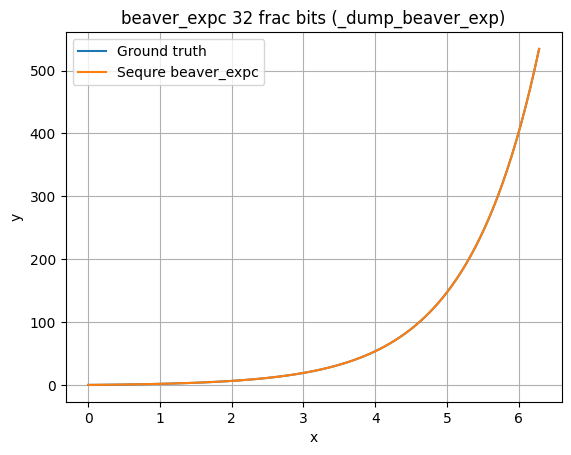

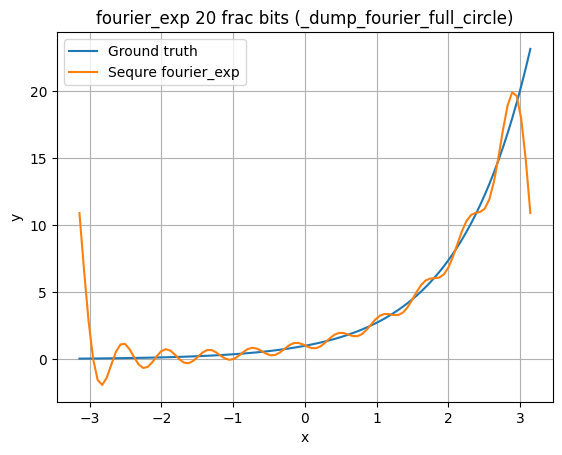

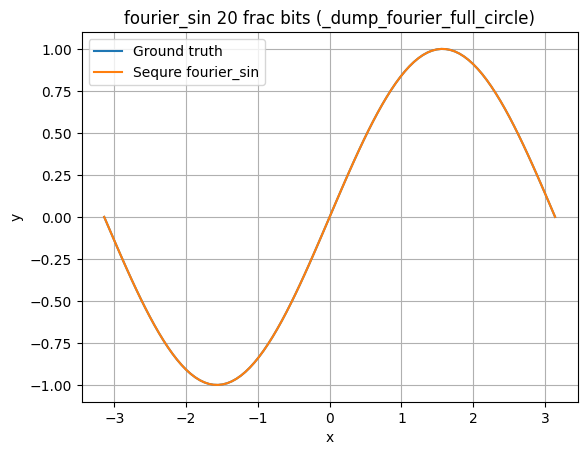

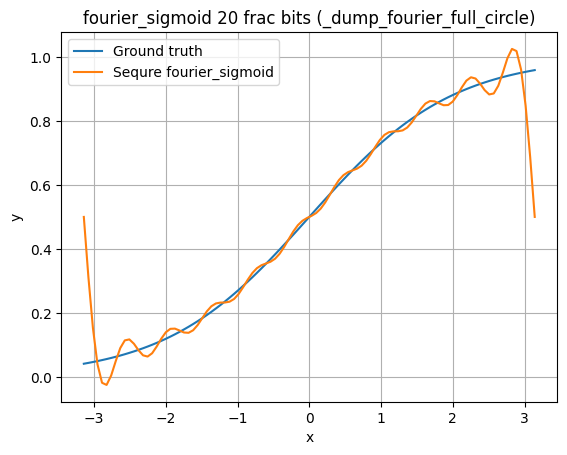

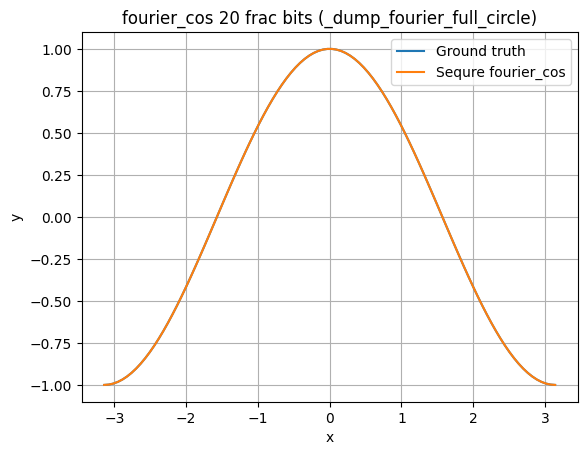

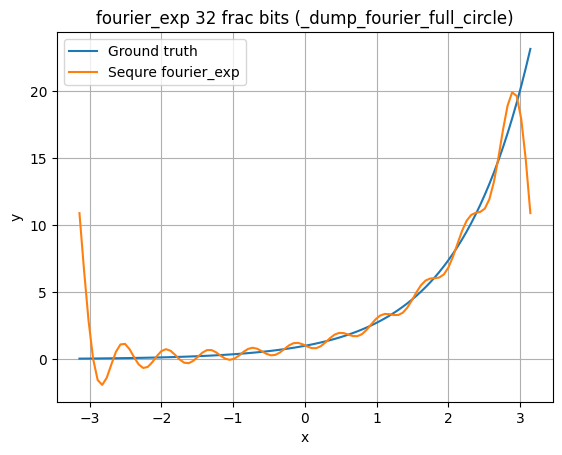

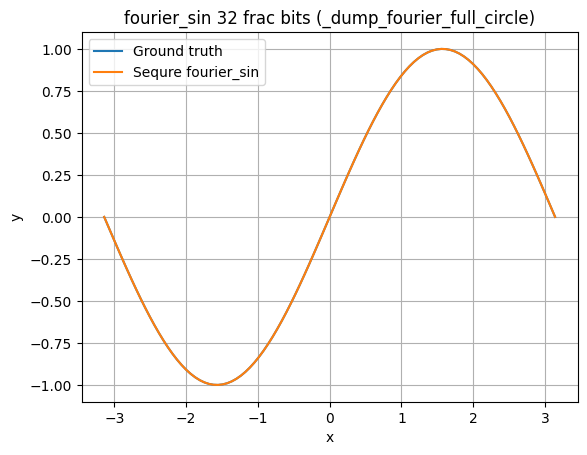

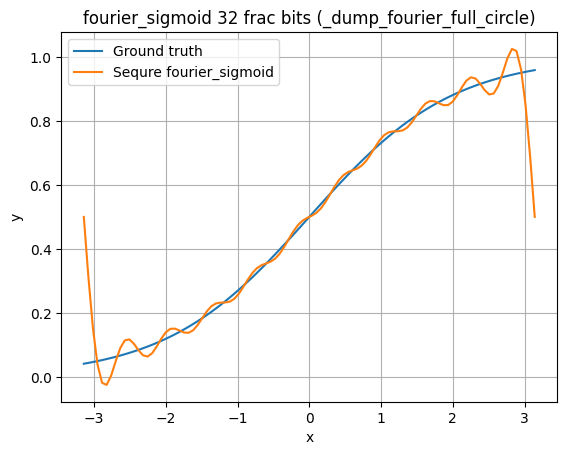

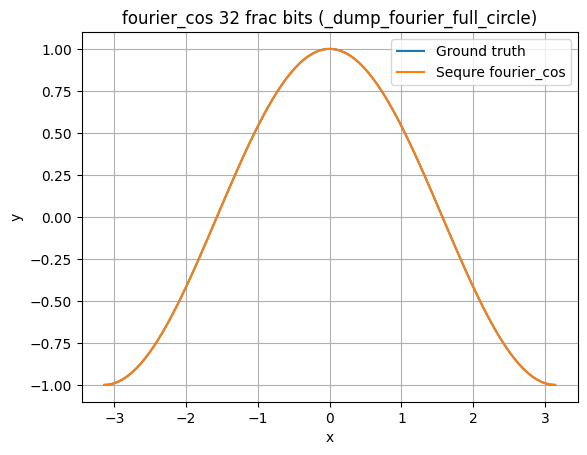

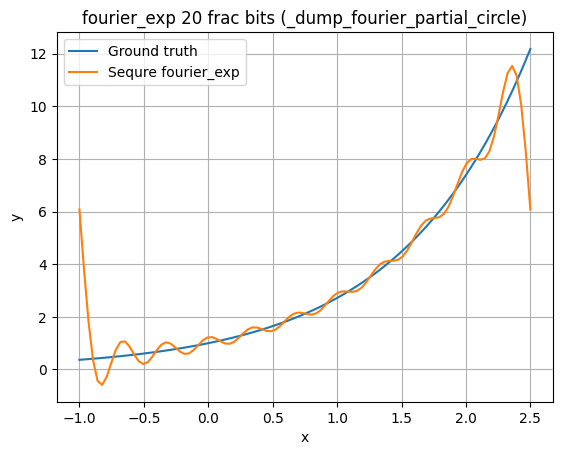

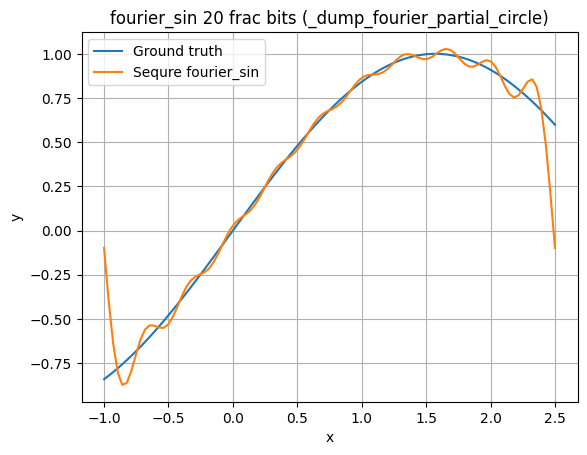

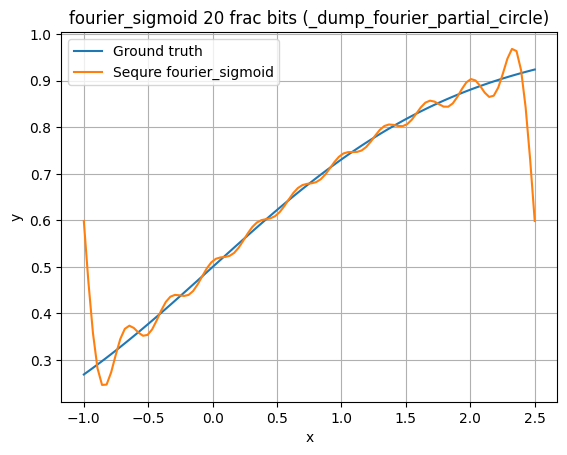

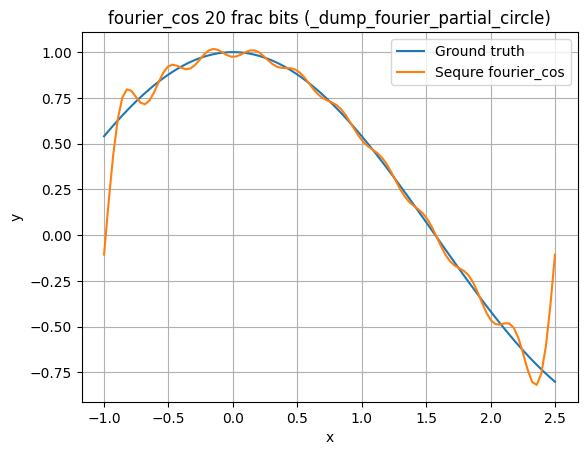

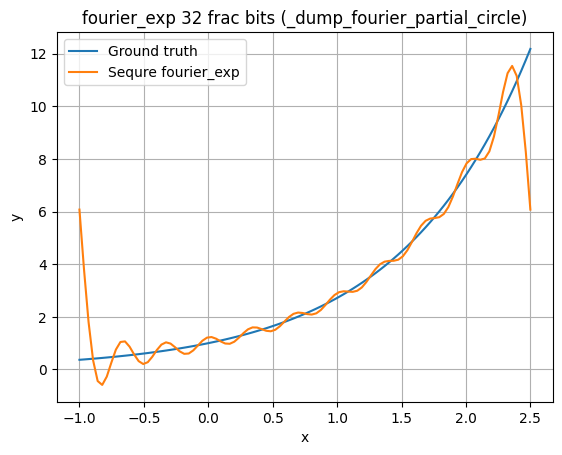

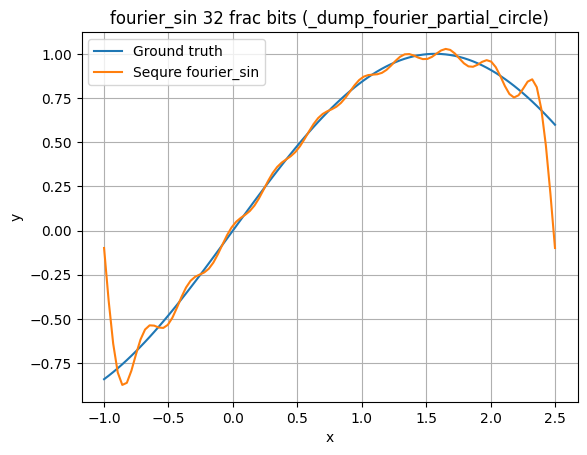

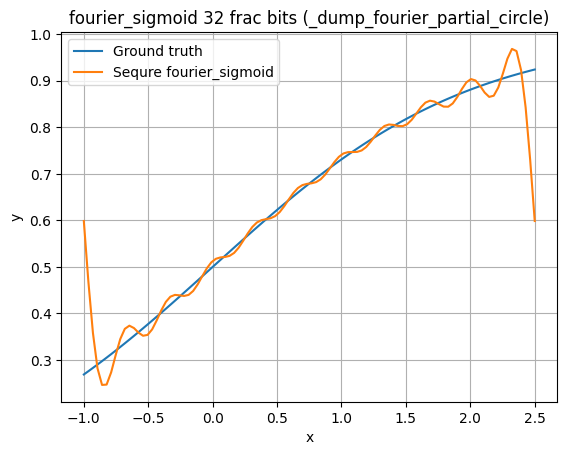

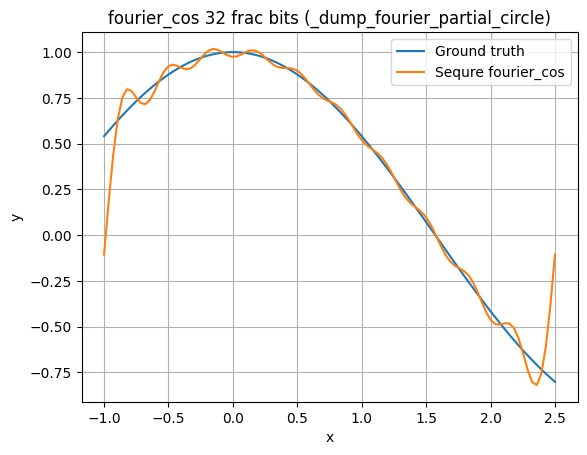

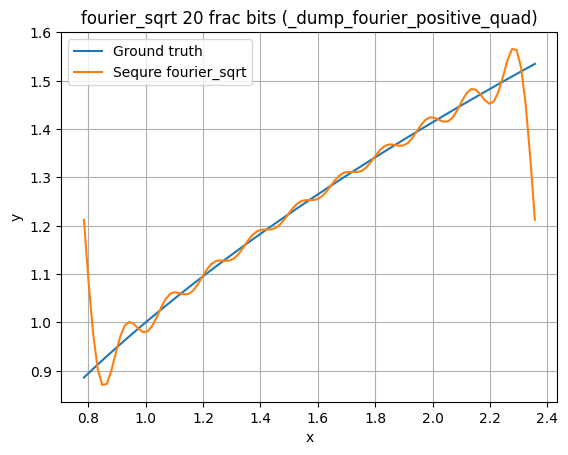

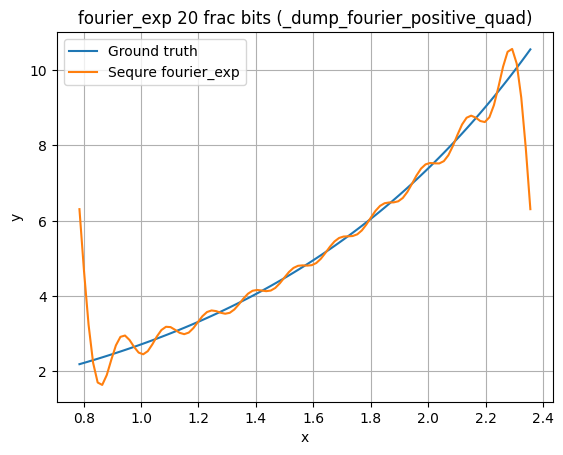

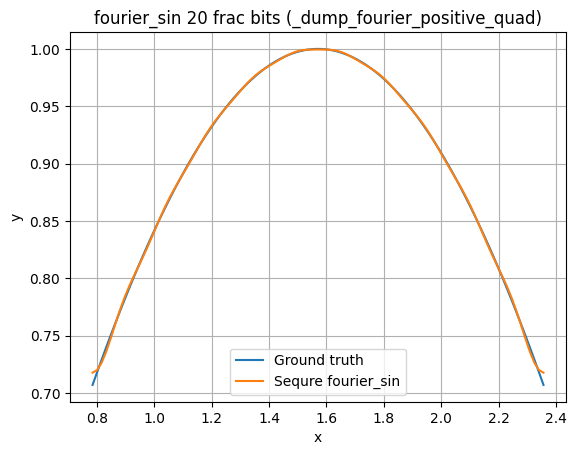

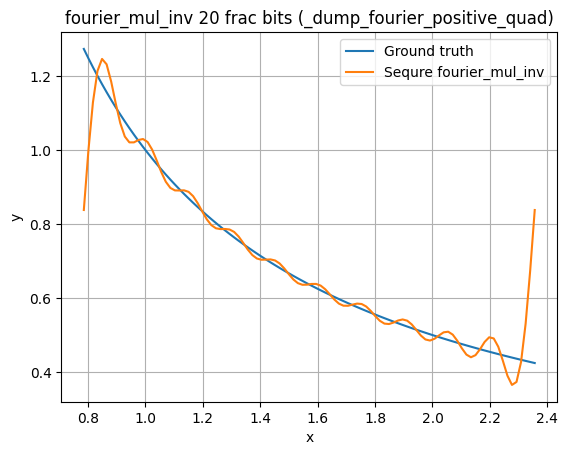

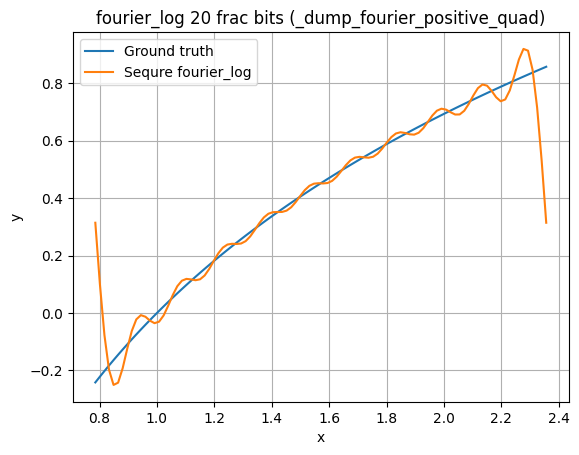

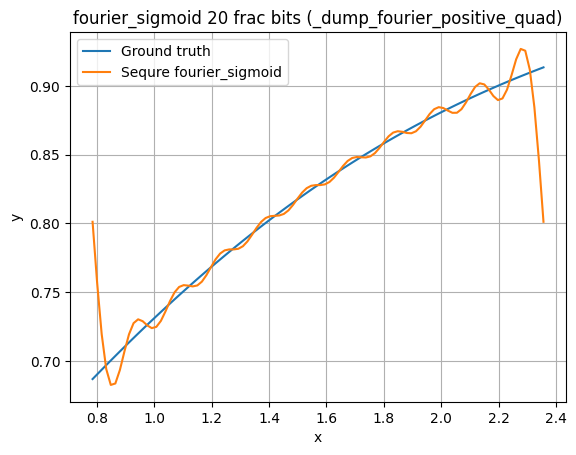

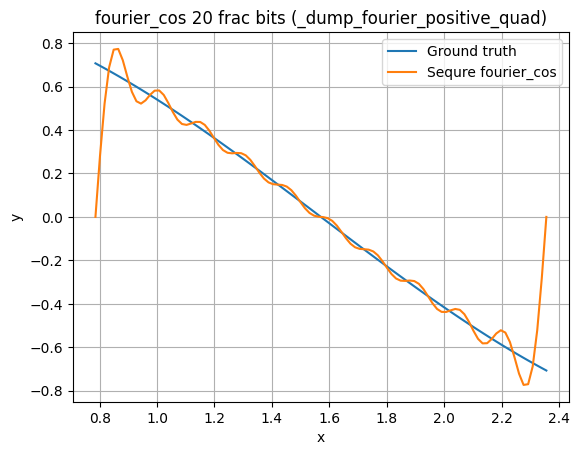

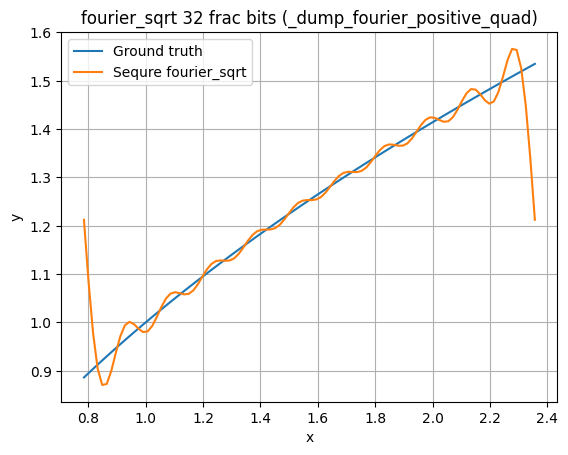

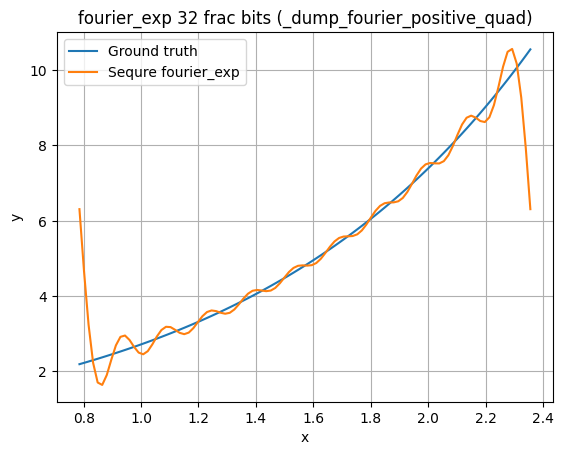

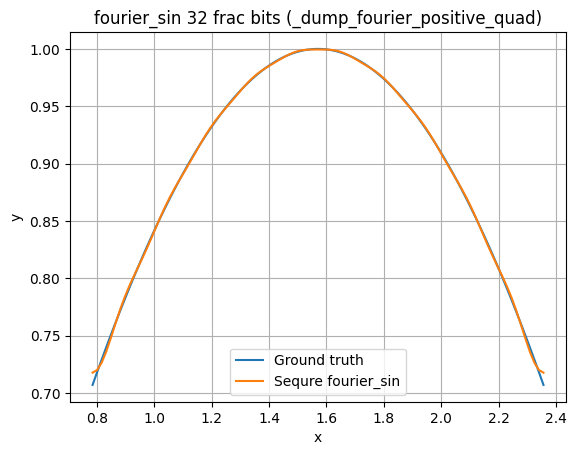

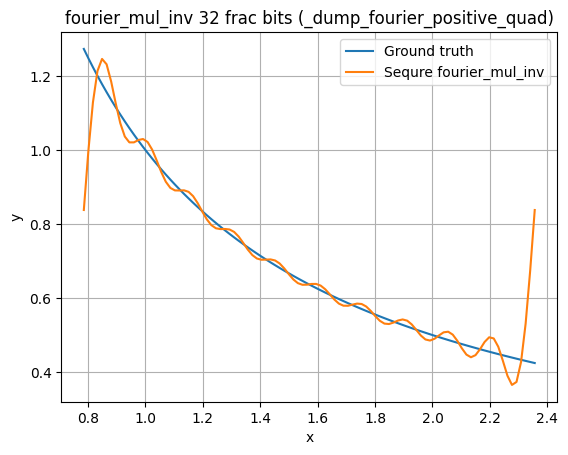

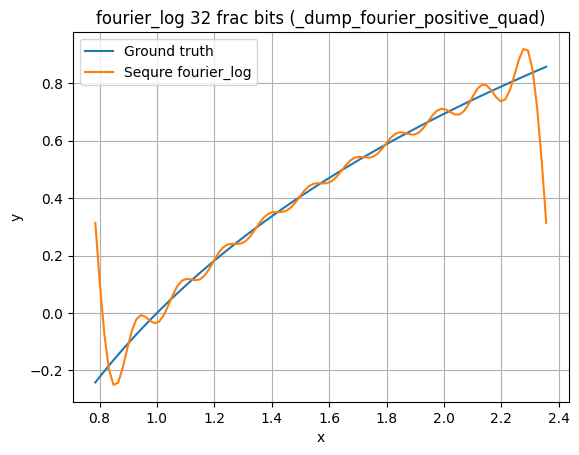

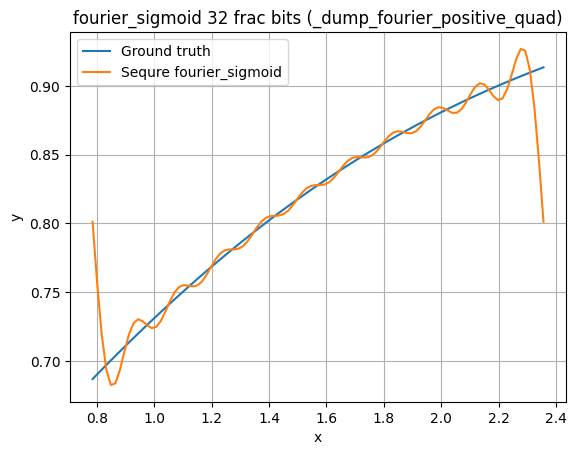

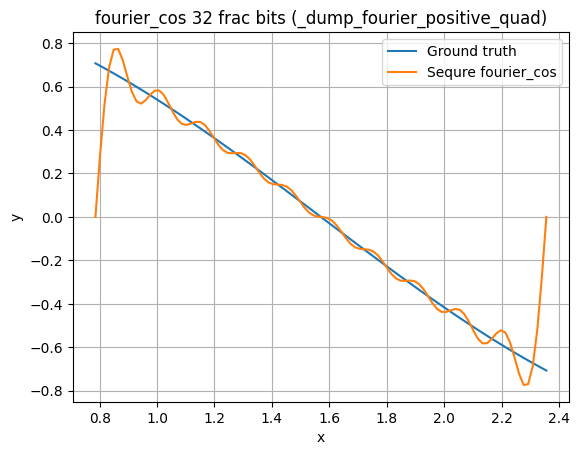

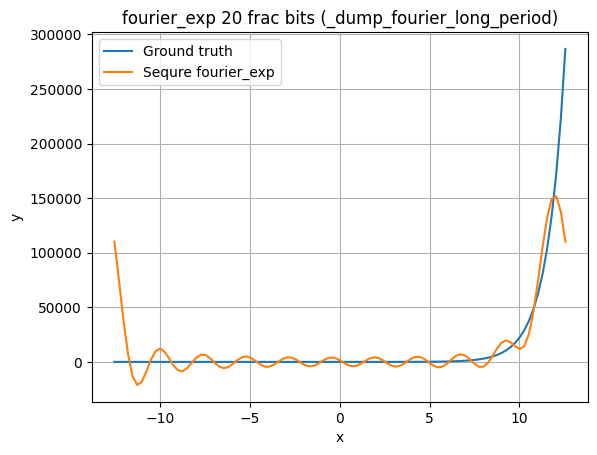

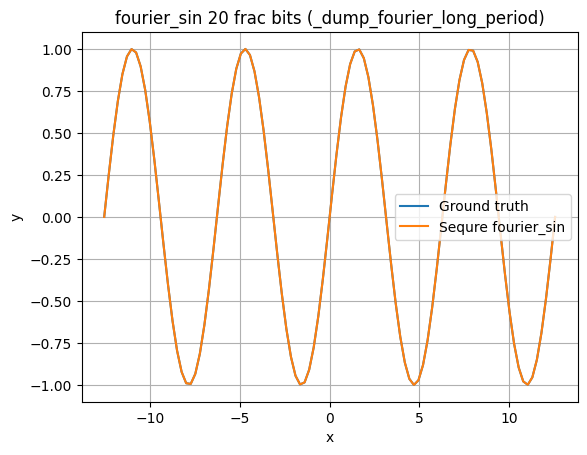

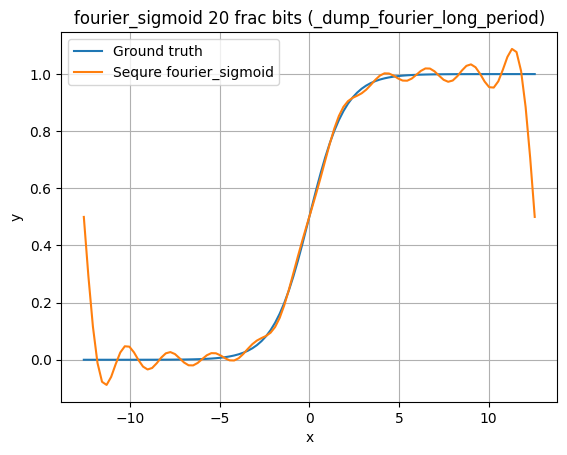

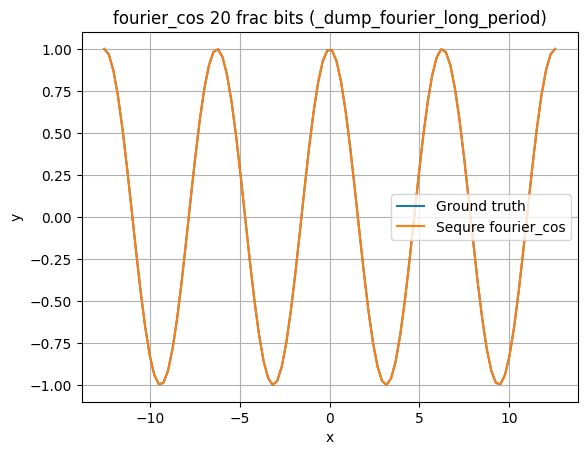

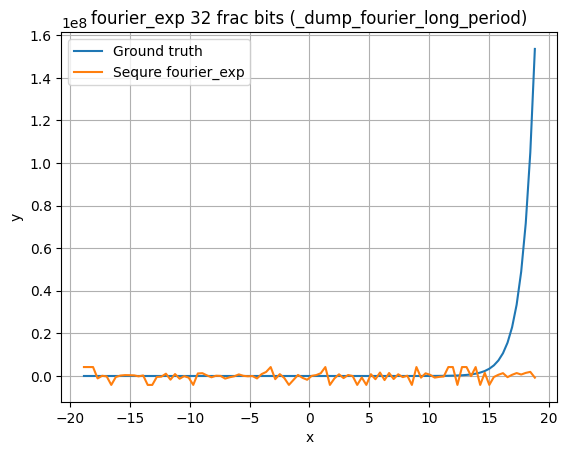

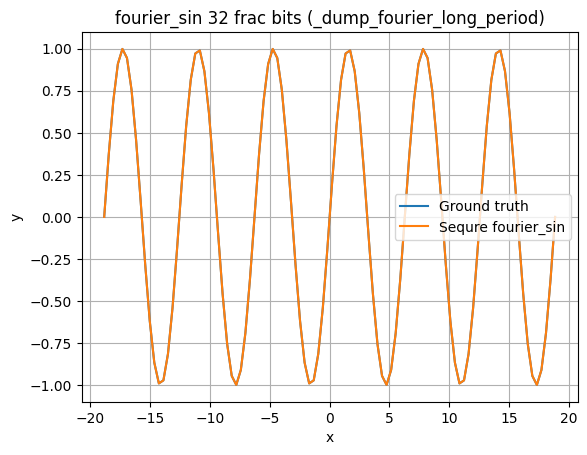

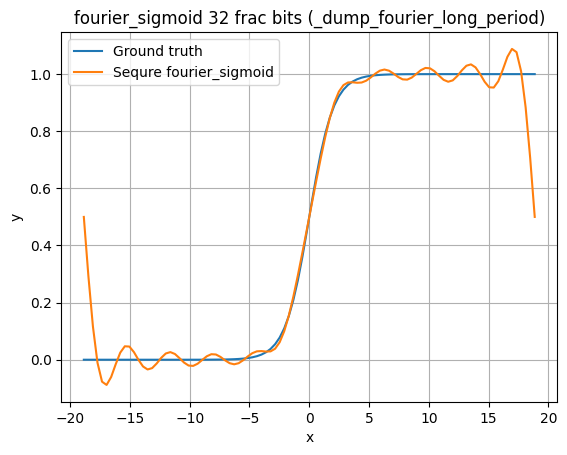

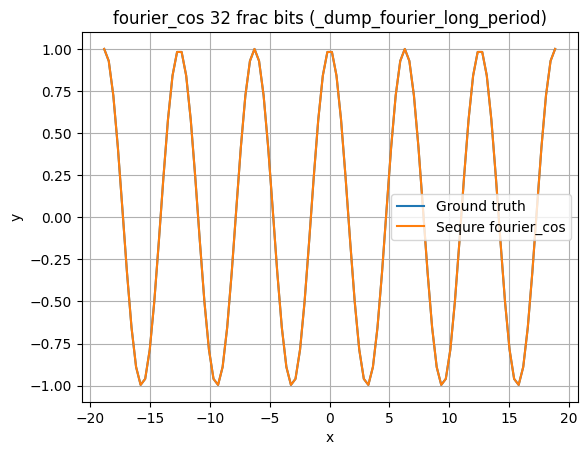

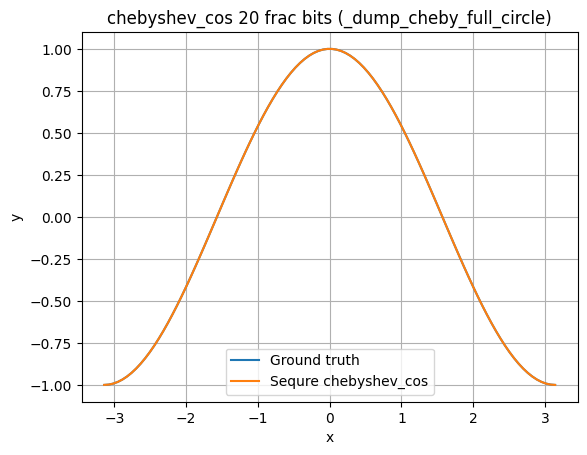

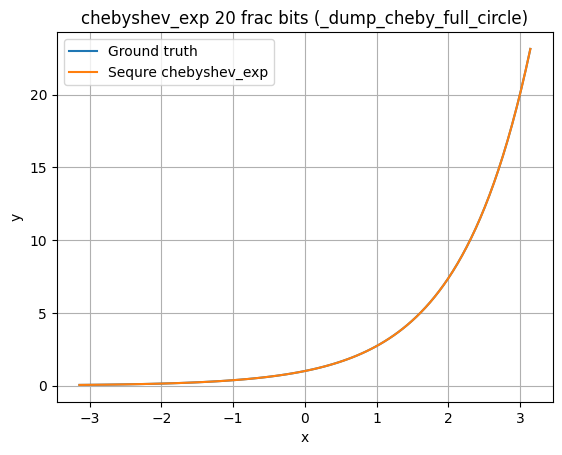

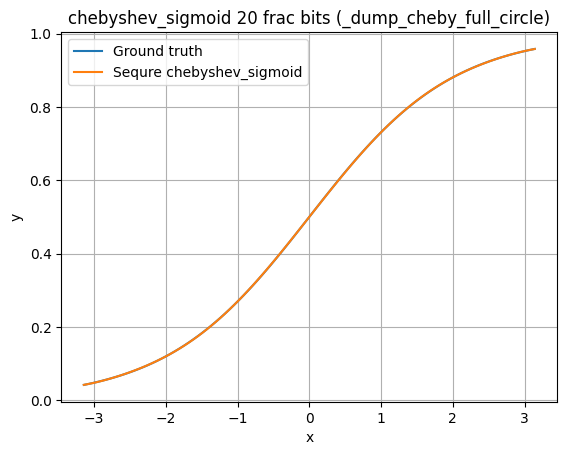

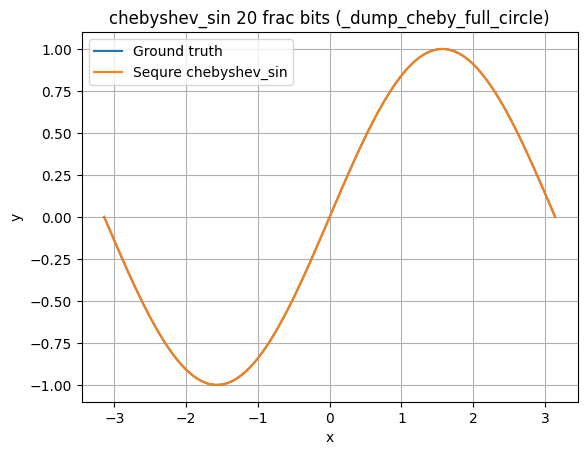

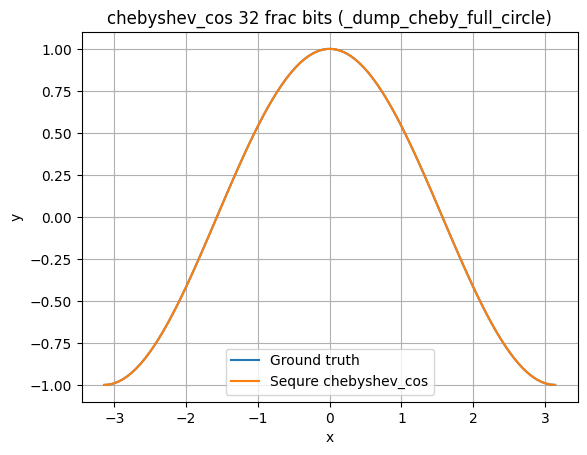

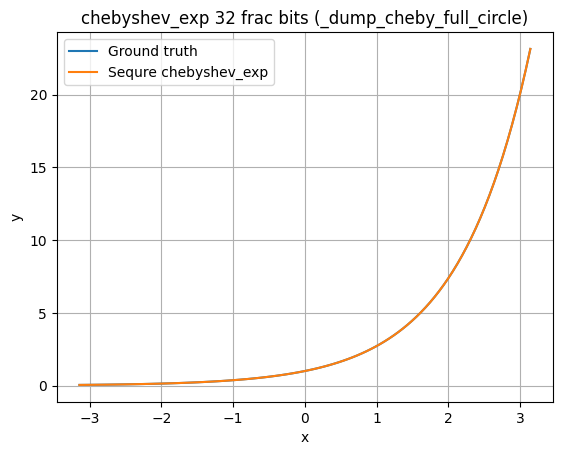

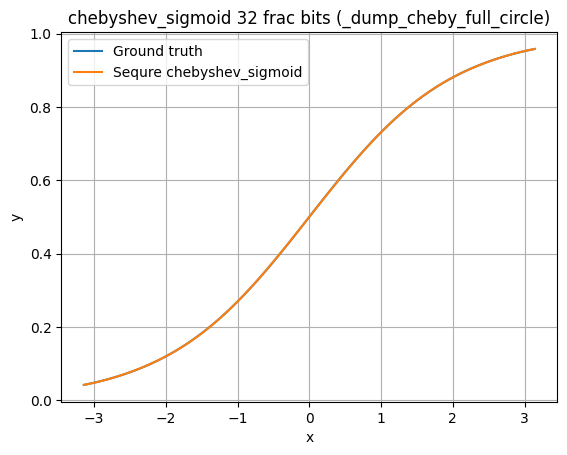

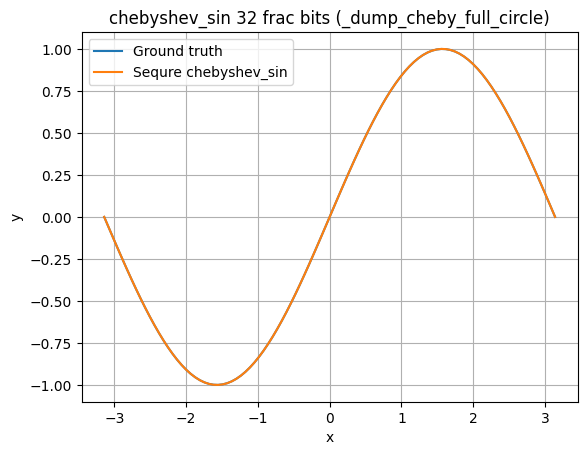

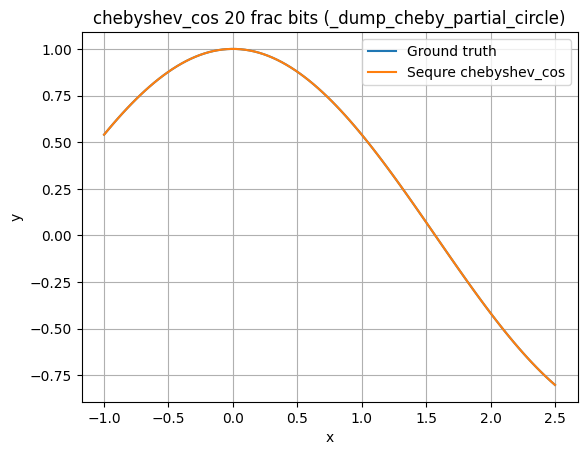

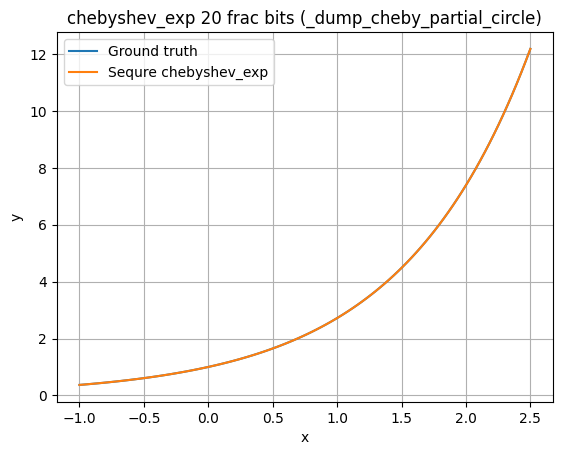

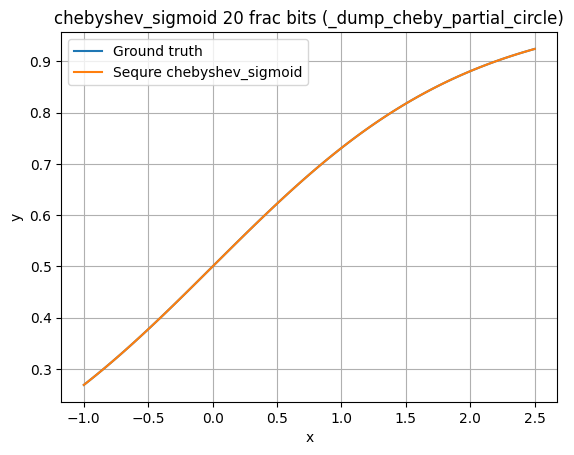

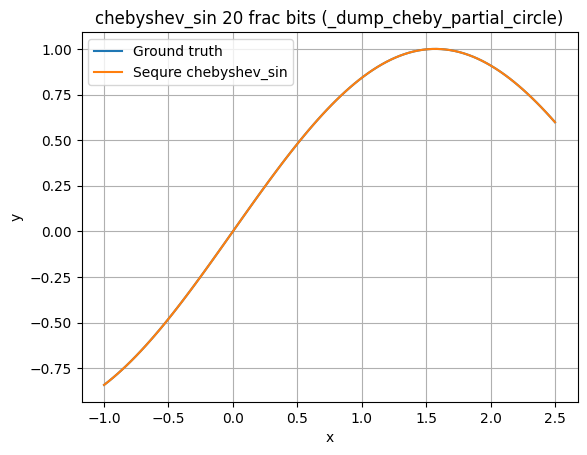

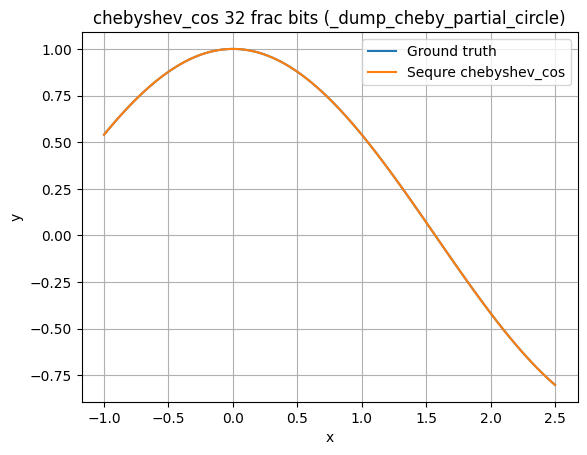

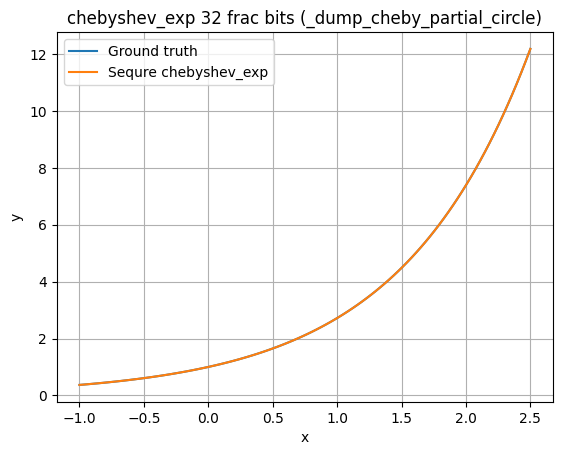

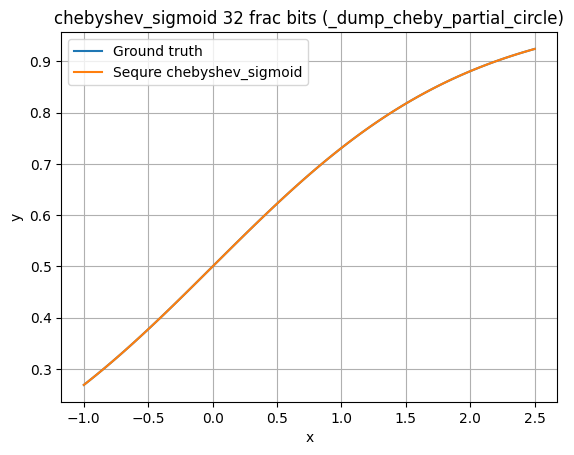

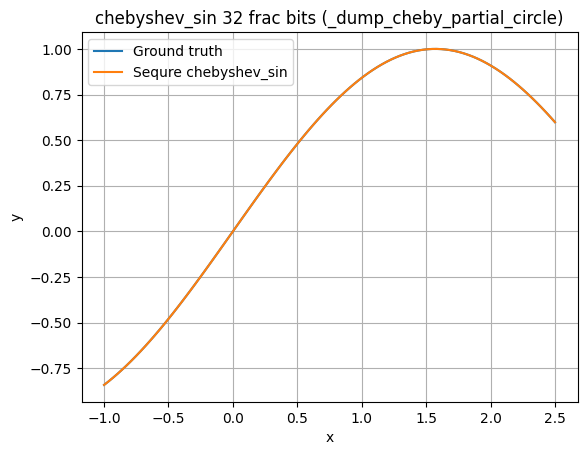

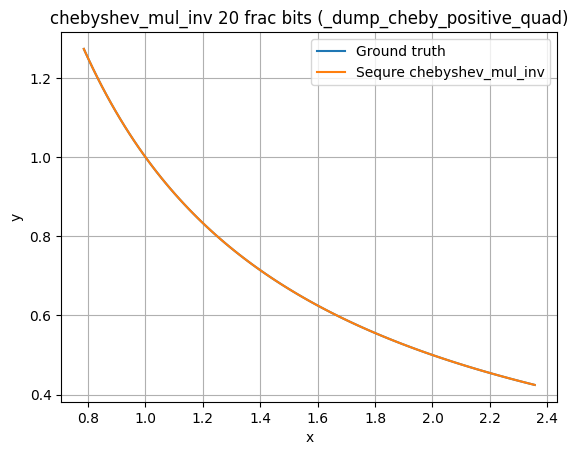

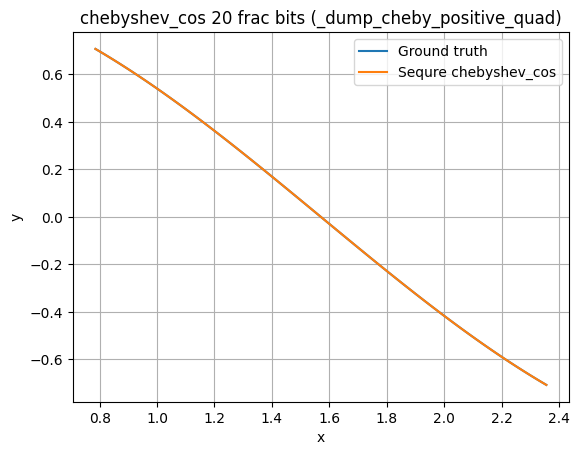

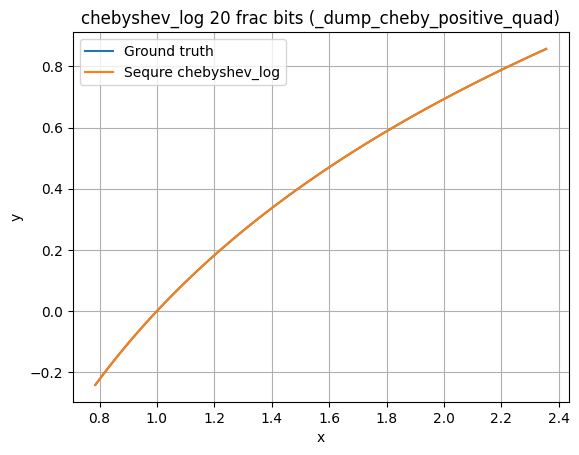

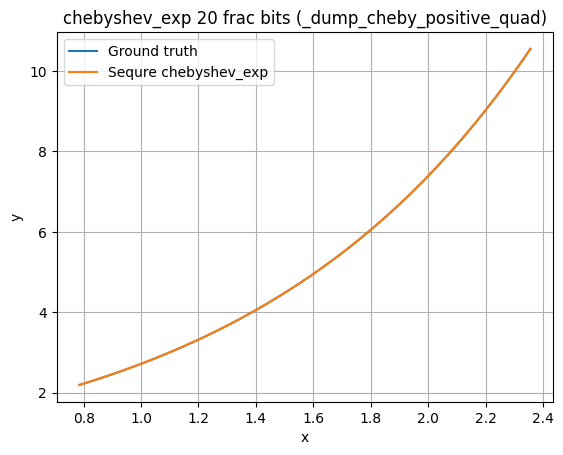

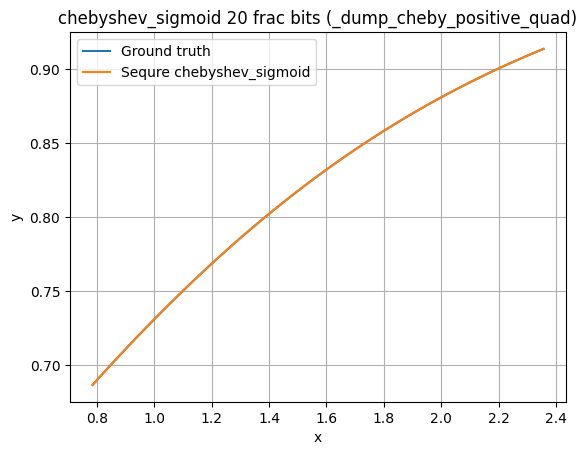

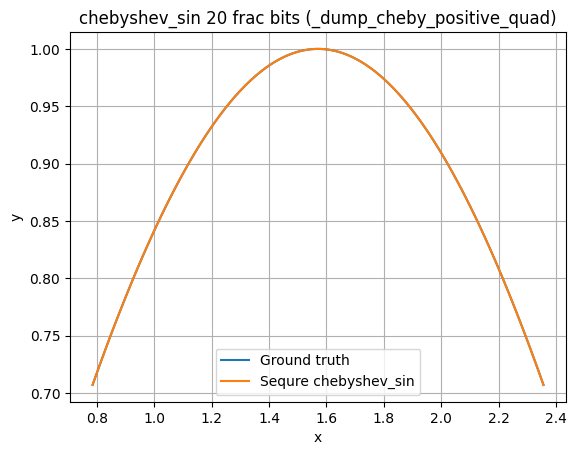

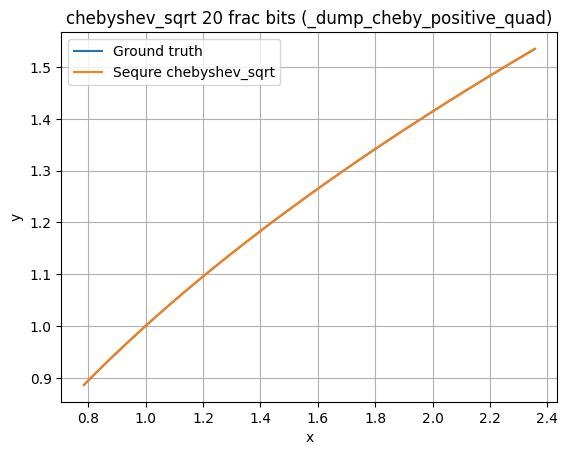

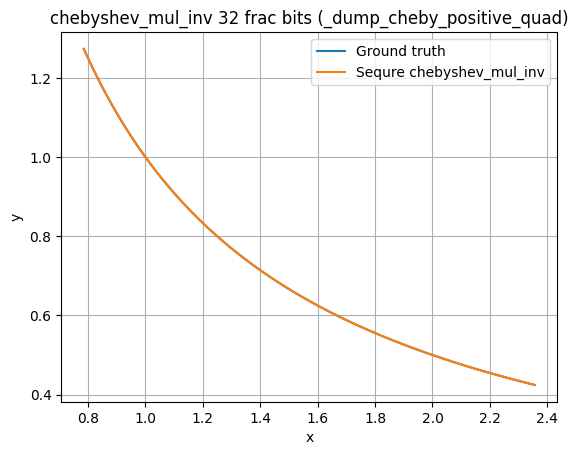

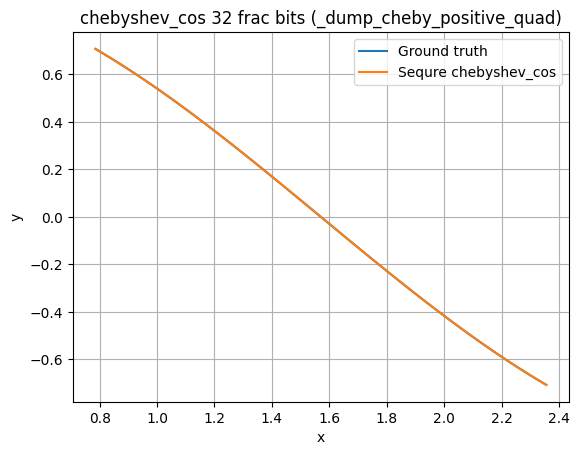

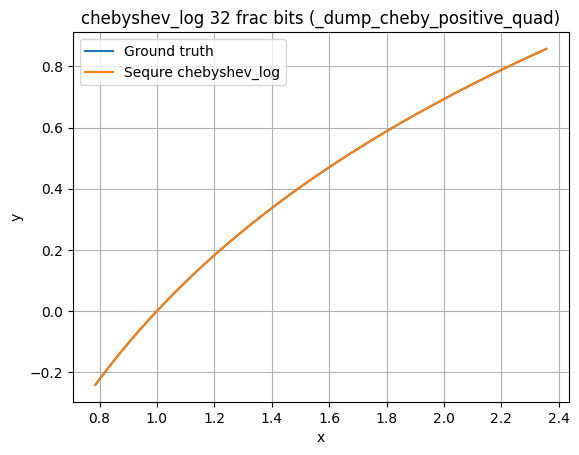

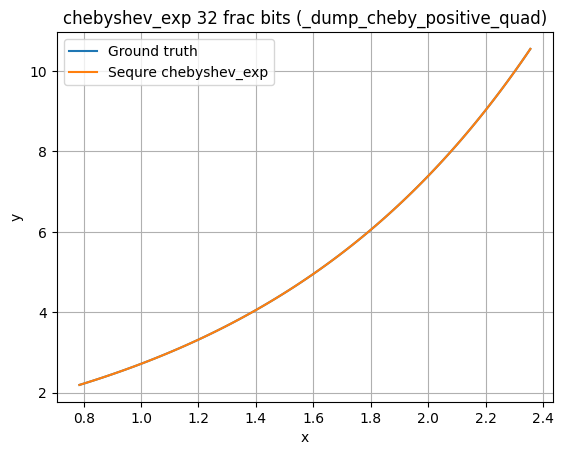

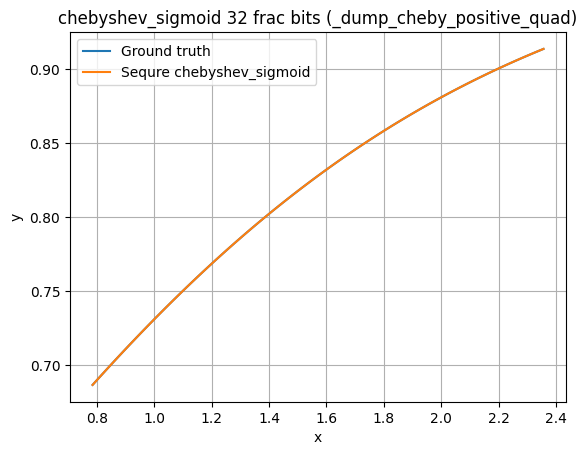

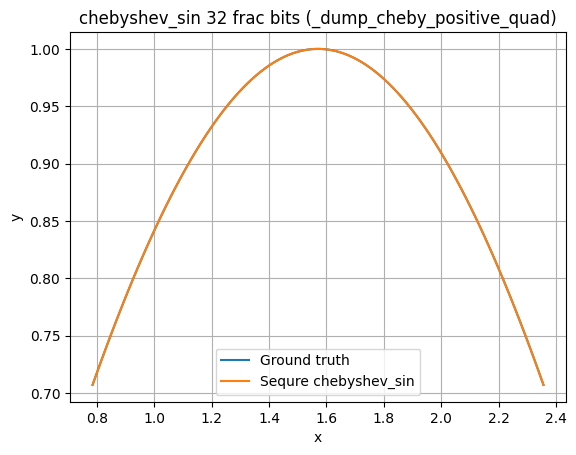

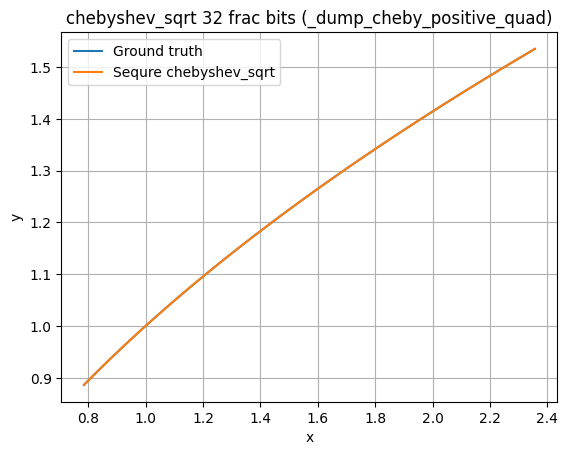

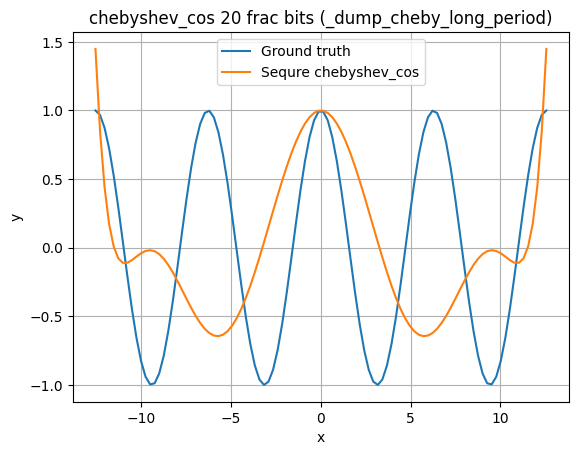

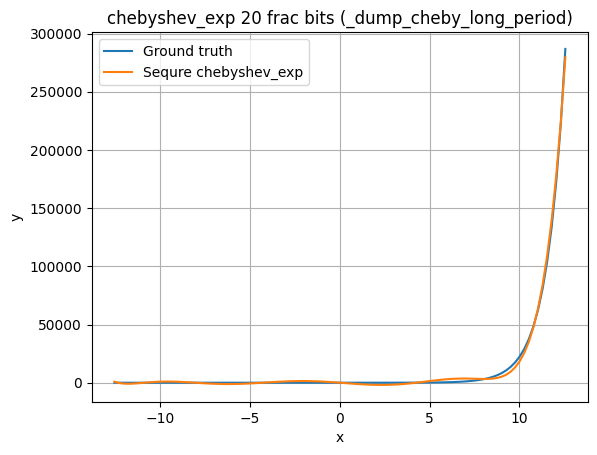

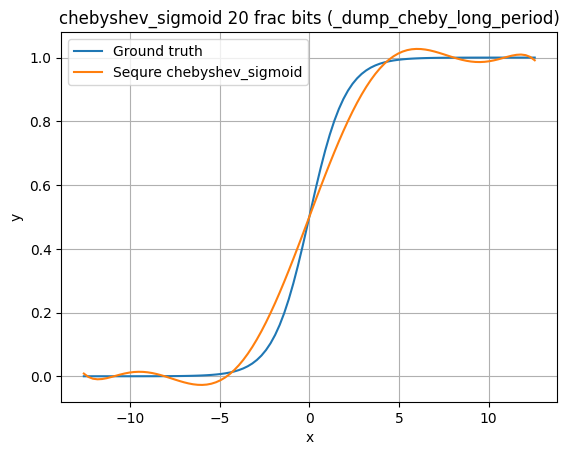

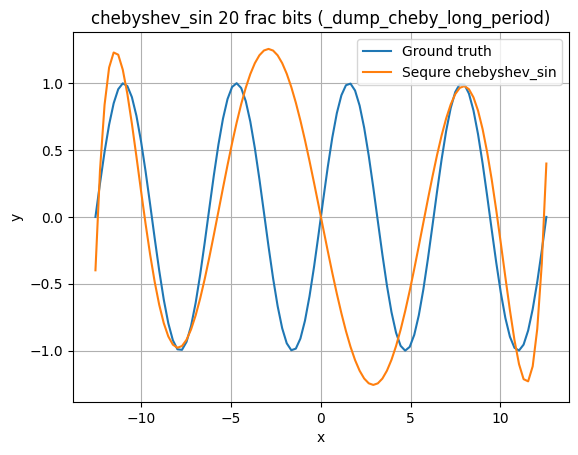

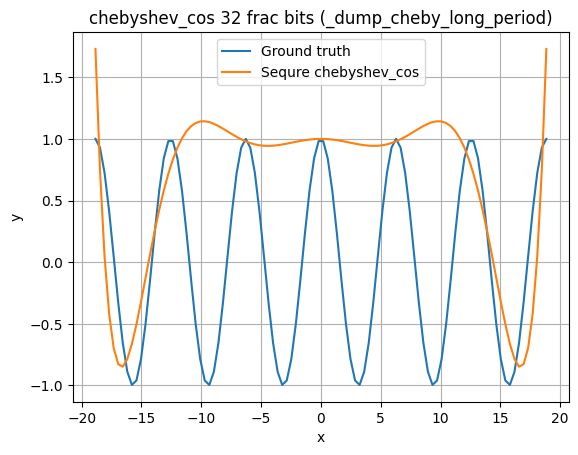

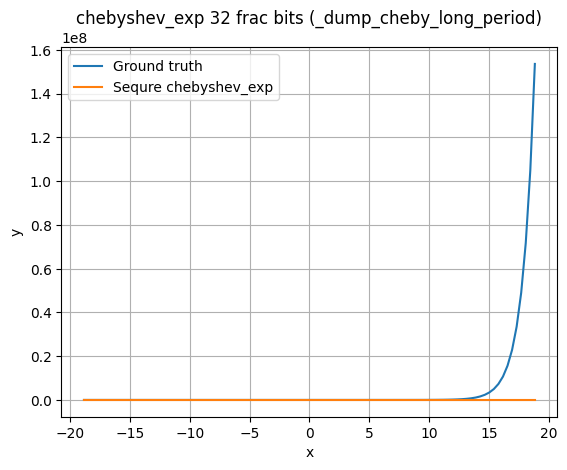

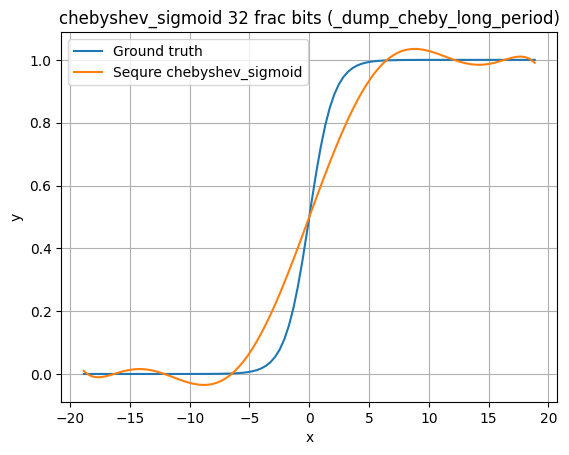

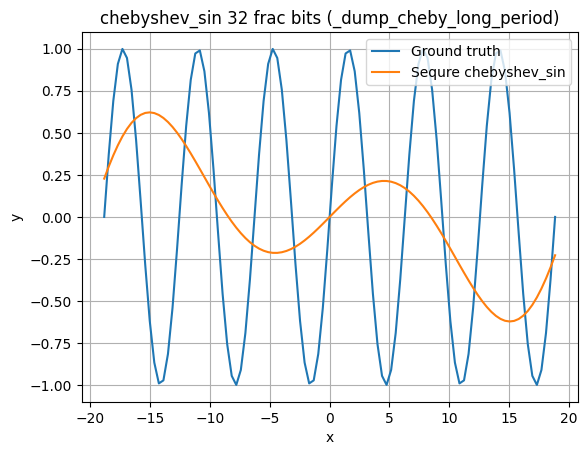

In [36]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot(title, label, x, result, expected):
    plt.plot(x, expected, label=f'Ground truth')
    plt.plot(x, result, label=f'Sequre {label}')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

def mae(result, expected):
    return np.mean(np.abs(np.array(result) - np.array(expected)))


# Until Codon Jupyter is fixed: Read the data from file
dump_files = [
    "_dump_beaver_trig",
    "_dump_beaver_exp",
    "_dump_fourier_full_circle",
    "_dump_fourier_partial_circle",
    "_dump_fourier_positive_quad",
    "_dump_fourier_long_period",
    "_dump_cheby_full_circle",
    "_dump_cheby_partial_circle",
    "_dump_cheby_positive_quad",
    "_dump_cheby_long_period"
]

nbit_fs = [20, 32]

df_data = {
    'Method': [],
    'Interval': [],
    'MAE': [],
    'Runtime': []}

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        with open(f"{dump_file}_{nbit_f}.p", "rb") as f:
            data = pickle.load(f)
            x = data['x']
            interval = f"({round(min(x), 2)}, {round(max(x), 2)})"
            for k, v in data.items():
                if k == 'x' or k.endswith("_expected") or k.endswith("_time"):
                    continue
                expected = data[f"{k}_expected"]
                runtime = round(data[f"{k}_time"][0], 5)
                
                df_data['Method'].append(f"{k}_{nbit_f}")
                df_data['Interval'].append(interval)
                df_data['MAE'].append(mae(v, expected))
                df_data['Runtime'].append(runtime)
                
                plot(f"{k} {nbit_f} frac bits ({dump_file})", k, x, v, expected)

df = pd.DataFrame(df_data)

In [37]:
df[df['Method'].str.contains('sin')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
72,chebyshev_sin_32,"(0.79, 2.36)",4.049889e-10,0.00096
3,beaver_sin_32,"(-3.14, 3.14)",5.202096e-10,0.00030
11,fourier_sin_32,"(-3.14, 3.14)",5.223059e-10,0.14415
41,fourier_sin_32,"(-18.85, 18.85)",2.737481e-09,0.00952
59,chebyshev_sin_32,"(-1.0, 2.5)",7.257742e-07,0.00128
65,chebyshev_sin_20,"(0.79, 2.36)",1.516451e-06,0.00090
55,chebyshev_sin_20,"(-1.0, 2.5)",1.778459e-06,0.00025
7,fourier_sin_20,"(-3.14, 3.14)",2.339606e-06,0.14049
1,beaver_sin_20,"(-3.14, 3.14)",2.349065e-06,0.00007
37,fourier_sin_20,"(-12.57, 12.57)",8.053082e-06,0.01025


In [38]:
df[df['Method'].str.contains('cos')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
2,beaver_cos_32,"(-3.14, 3.14)",5.429638e-10,0.00022
13,fourier_cos_32,"(-3.14, 3.14)",5.565842e-10,0.00912
68,chebyshev_cos_32,"(0.79, 2.36)",9.152316e-10,0.00031
43,fourier_cos_32,"(-18.85, 18.85)",2.806821e-09,0.01041
56,chebyshev_cos_32,"(-1.0, 2.5)",6.760503e-07,0.00030
61,chebyshev_cos_20,"(0.79, 2.36)",1.460093e-06,0.00057
52,chebyshev_cos_20,"(-1.0, 2.5)",1.961580e-06,0.00092
9,fourier_cos_20,"(-3.14, 3.14)",2.156730e-06,0.00945
0,beaver_cos_20,"(-3.14, 3.14)",2.246086e-06,0.00031
39,fourier_cos_20,"(-12.57, 12.57)",7.917967e-06,0.01016


In [39]:
df[df['Method'].str.contains('exp')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
70,chebyshev_exp_32,"(0.79, 2.36)",4.102843e-09,0.00063
5,beaver_expc_32,"(0.0, 6.28)",7.686361e-08,0.00817
57,chebyshev_exp_32,"(-1.0, 2.5)",2.426197e-06,0.00030
53,chebyshev_exp_20,"(-1.0, 2.5)",3.436189e-06,0.00061
63,chebyshev_exp_20,"(0.79, 2.36)",6.644370e-06,0.00025
45,chebyshev_exp_20,"(-3.14, 3.14)",2.593025e-04,0.00027
49,chebyshev_exp_32,"(-3.14, 3.14)",2.600739e-04,0.00206
4,beaver_expc_20,"(0.0, 6.28)",2.872153e-04,0.00567
30,fourier_exp_32,"(0.79, 2.36)",3.009865e-01,0.01231
23,fourier_exp_20,"(0.79, 2.36)",3.009870e-01,0.01262


In [40]:
df[df['Method'].str.contains('sigmoid')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
71,chebyshev_sigmoid_32,"(0.79, 2.36)",4.543197e-10,0.00136
58,chebyshev_sigmoid_32,"(-1.0, 2.5)",1.557569e-06,0.00031
64,chebyshev_sigmoid_20,"(0.79, 2.36)",1.626935e-06,0.00058
54,chebyshev_sigmoid_20,"(-1.0, 2.5)",2.345127e-06,0.00090
46,chebyshev_sigmoid_20,"(-3.14, 3.14)",2.293331e-04,0.00032
50,chebyshev_sigmoid_32,"(-3.14, 3.14)",2.293995e-04,0.00034
27,fourier_sigmoid_20,"(0.79, 2.36)",8.160868e-03,0.00965
34,fourier_sigmoid_32,"(0.79, 2.36)",8.161617e-03,0.00911
16,fourier_sigmoid_20,"(-1.0, 2.5)",2.360780e-02,0.00928
20,fourier_sigmoid_32,"(-1.0, 2.5)",2.360811e-02,0.00891


In [41]:
df[df['Method'].str.contains('sqrt')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
73,chebyshev_sqrt_32,"(0.79, 2.36)",1.133262e-07,0.00030
66,chebyshev_sqrt_20,"(0.79, 2.36)",1.552786e-06,0.00061
22,fourier_sqrt_20,"(0.79, 2.36)",2.336440e-02,0.00915
29,fourier_sqrt_32,"(0.79, 2.36)",2.336460e-02,0.00933


In [42]:
df[df['Method'].str.contains('mul_inv')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
60,chebyshev_mul_inv_20,"(0.79, 2.36)",0.000006,0.00025
67,chebyshev_mul_inv_32,"(0.79, 2.36)",0.000006,0.00093
25,fourier_mul_inv_20,"(0.79, 2.36)",0.030547,0.00983
32,fourier_mul_inv_32,"(0.79, 2.36)",0.030547,0.00989


In [43]:
df[df['Method'].str.contains('log')].sort_values(by='MAE')

,Method,Interval,MAE,Runtime
69,chebyshev_log_32,"(0.79, 2.36)",9.809986e-07,0.00105
62,chebyshev_log_20,"(0.79, 2.36)",1.741530e-06,0.00029
26,fourier_log_20,"(0.79, 2.36)",3.955924e-02,0.00961
33,fourier_log_32,"(0.79, 2.36)",3.955955e-02,0.01024
